## Setup imports + paths

In [1]:
# ============================================
# Cell 1 — Setup: imports, paths, class registry
# ============================================
import os, sys, time, json, random, glob
from pathlib import Path
from collections import defaultdict

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

import trimesh

# Reproducibility
SEED = 42
random.seed(SEED); np.random.seed(SEED)

REPO_ROOT = Path('/Users/dosvatsky/3D Object Detection')
MESH_ROOT = REPO_ROOT / 'data' / 'mesh_dataset_v1'
SCENE_OUT = REPO_ROOT / 'data' / 'synthetic_scenes_v1'
SCENE_OUT.mkdir(parents=True, exist_ok=True)

# 27 classes in fixed order — this order MUST match later VoteNet config
# Furniture first (matches our SUN RGB-D class order for backbone compatibility)
FURNITURE_CLASSES = [
    'bed', 'table', 'sofa', 'chair', 'toilet',
    'desk', 'dresser', 'night_stand', 'bookshelf', 'bathtub',
]
# Military classes second
MILITARY_CLASSES = [
    'ammo_box', 'binoculars', 'combat_knife', 'flashlight',
    'gas_mask', 'hand_grenade', 'helmet', 'magazine',
    'military_radio', 'pistol', 'rifle', 'rocket_launcher',
    'shotgun', 'sniper_rifle', 'tactical_backpack',
    'tactical_vest', 'wire_cutter',
]
CLASS_NAMES = FURNITURE_CLASSES + MILITARY_CLASSES  # 10 + 17 = 27
CLASS_TO_IDX = {n: i for i, n in enumerate(CLASS_NAMES)}
NUM_CLASSES = len(CLASS_NAMES)

# Real-world dimensions per class (meters) — used to scale meshes uniformly
# These are typical longest-axis lengths; meshes get scaled to match
CLASS_REAL_SIZE = {
    # Furniture
    'bed':            2.0,
    'table':          1.5,
    'sofa':           2.0,
    'chair':          0.85,
    'toilet':         0.70,
    'desk':           1.4,
    'dresser':        1.2,
    'night_stand':    0.55,
    'bookshelf':      1.5,
    'bathtub':        1.7,
    # Military
    'ammo_box':       0.35,
    'binoculars':     0.18,
    'combat_knife':   0.30,
    'flashlight':     0.20,
    'gas_mask':       0.28,
    'hand_grenade':   0.11,
    'helmet':         0.28,
    'magazine':       0.15,
    'military_radio': 0.22,
    'pistol':         0.22,
    'rifle':          0.95,
    'rocket_launcher':1.10,
    'shotgun':        1.00,
    'sniper_rifle':   1.20,
    'tactical_backpack': 0.55,
    'tactical_vest':  0.50,
    'wire_cutter':    0.22,
}

assert set(CLASS_REAL_SIZE.keys()) == set(CLASS_NAMES), 'Class lists must match'

print(f'Repo:       {REPO_ROOT}')
print(f'Mesh data:  {MESH_ROOT}')
print(f'Scene out:  {SCENE_OUT}')
print(f'\n{NUM_CLASSES} classes registered:')
for i, n in enumerate(CLASS_NAMES):
    cat = 'FURN' if n in FURNITURE_CLASSES else 'MIL '
    print(f'  {i:2d} [{cat}] {n:22s} target size {CLASS_REAL_SIZE[n]:.2f}m')

# Confirm Python can find trimesh
print(f'\ntrimesh version: {trimesh.__version__}')

Repo:       /Users/dosvatsky/3D Object Detection
Mesh data:  /Users/dosvatsky/3D Object Detection/data/mesh_dataset_v1
Scene out:  /Users/dosvatsky/3D Object Detection/data/synthetic_scenes_v1

27 classes registered:
   0 [FURN] bed                    target size 2.00m
   1 [FURN] table                  target size 1.50m
   2 [FURN] sofa                   target size 2.00m
   3 [FURN] chair                  target size 0.85m
   4 [FURN] toilet                 target size 0.70m
   5 [FURN] desk                   target size 1.40m
   6 [FURN] dresser                target size 1.20m
   7 [FURN] night_stand            target size 0.55m
   8 [FURN] bookshelf              target size 1.50m
   9 [FURN] bathtub                target size 1.70m
  10 [MIL ] ammo_box               target size 0.35m
  11 [MIL ] binoculars             target size 0.18m
  12 [MIL ] combat_knife           target size 0.30m
  13 [MIL ] flashlight             target size 0.20m
  14 [MIL ] gas_mask               target

## Mesh verification and registry build

In [2]:
# ============================================
# Cell 2 — Verify all 277 meshes load + build registry
# ============================================
t0 = time.time()

MESH_REGISTRY = {}   # class_name -> list of mesh file paths
mesh_stats = {'ok': 0, 'failed': [], 'too_small': [], 'too_large': []}

def safe_load_mesh(path):
    """Load mesh, handling Scene-containing .glb files. Returns trimesh.Trimesh or None."""
    try:
        m = trimesh.load(str(path), force='mesh')
        if isinstance(m, trimesh.Scene):
            geoms = list(m.geometry.values())
            if not geoms:
                return None, 'empty scene'
            m = trimesh.util.concatenate(geoms)
        if not isinstance(m, trimesh.Trimesh):
            return None, f'unexpected type {type(m).__name__}'
        if len(m.vertices) < 10:
            return None, f'too few vertices ({len(m.vertices)})'
        return m, None
    except Exception as e:
        return None, str(e)[:100]


print('Verifying meshes (this takes 1-2 min)...\n')

for category, classes in [('furniture', FURNITURE_CLASSES),
                          ('military',  MILITARY_CLASSES)]:
    print(f'=== {category.upper()} ===')
    for class_name in classes:
        class_dir = MESH_ROOT / category / class_name
        if not class_dir.exists():
            print(f'  {class_name:22s} DIR MISSING: {class_dir}')
            MESH_REGISTRY[class_name] = []
            continue

        mesh_paths = sorted(list(class_dir.glob('*.glb')) +
                            list(class_dir.glob('*.GLB')) +
                            list(class_dir.glob('*.off')))

        valid = []
        for mp in mesh_paths:
            mesh, err = safe_load_mesh(mp)
            if mesh is None:
                mesh_stats['failed'].append((str(mp), err))
                continue
            n_v = len(mesh.vertices)
            if n_v > 500_000:
                mesh_stats['too_large'].append((str(mp), n_v))
                # Still add it — we'll decimate during loading later
            valid.append(str(mp))
            mesh_stats['ok'] += 1

        MESH_REGISTRY[class_name] = valid
        status = '✅' if len(valid) >= 5 else '⚠️ '
        print(f'  {status} {class_name:22s} {len(valid):3d}/{len(mesh_paths):3d} valid')

elapsed = time.time() - t0
print(f'\n=== SUMMARY ({elapsed:.0f}s) ===')
print(f'  Total valid meshes: {mesh_stats["ok"]}')
print(f'  Failed loads:       {len(mesh_stats["failed"])}')
print(f'  Too-large (>500k):  {len(mesh_stats["too_large"])}')

if mesh_stats['failed']:
    print(f'\nFAILED meshes (first 10):')
    for p, e in mesh_stats['failed'][:10]:
        print(f'  {Path(p).name}: {e}')

if mesh_stats['too_large']:
    print(f'\nTOO LARGE — will be auto-decimated:')
    for p, n in mesh_stats['too_large'][:10]:
        print(f'  {Path(p).name}: {n} vertices')

# Confirm coverage
classes_with_too_few = [n for n in CLASS_NAMES if len(MESH_REGISTRY.get(n, [])) < 5]
if classes_with_too_few:
    print(f'\n⚠️  Classes with <5 valid meshes (need attention):')
    for n in classes_with_too_few:
        print(f'  {n}: {len(MESH_REGISTRY.get(n, []))}')
else:
    print(f'\n✅ All 27 classes have ≥5 valid meshes. Registry ready.')

Verifying meshes (this takes 1-2 min)...

=== FURNITURE ===
  ✅ bed                     10/ 10 valid
  ✅ table                   10/ 10 valid
  ✅ sofa                    10/ 10 valid
  ✅ chair                   10/ 10 valid
  ✅ toilet                  10/ 10 valid
  ✅ desk                    10/ 10 valid
  ✅ dresser                 10/ 10 valid
  ✅ night_stand             10/ 10 valid
  ✅ bookshelf               10/ 10 valid
  ✅ bathtub                 10/ 10 valid
=== MILITARY ===
  ✅ ammo_box                10/ 10 valid
  ✅ binoculars              10/ 10 valid
  ✅ combat_knife            10/ 10 valid
  ✅ flashlight              10/ 10 valid
  ✅ gas_mask                10/ 10 valid
  ✅ hand_grenade            10/ 10 valid
  ✅ helmet                  10/ 10 valid
  ✅ magazine                10/ 10 valid
  ✅ military_radio          17/ 17 valid
  ✅ pistol                  10/ 10 valid
  ✅ rifle                   10/ 10 valid
  ✅ rocket_launcher         10/ 10 valid
  ✅ shotgun          

## Helper Functions for Scene Generation

In [11]:
# ============================================
# Per-class orientation hints
# ============================================

# Classes whose longest axis should be horizontal
FLAT_CLASSES = {
    'bed', 'sofa', 'table', 'desk', 'bathtub',
    'pistol', 'rifle', 'shotgun', 'sniper_rifle',
    'combat_knife', 'rocket_launcher',
    'magazine', 'hand_grenade', 'wire_cutter',
    'ammo_box', 'binoculars'
}

# Classes whose longest axis should be vertical
TALL_CLASSES = {
    'chair', 'bookshelf', 'dresser', 'night_stand',
    'toilet', 'helmet', 'gas_mask', 'flashlight',
    'military_radio', 'tactical_backpack',
    'tactical_vest'
}


def auto_orient_mesh(m, class_name):
    """
    Rotate mesh so that its natural orientation matches
    the Y-up convention used by VoteNet.
    """
    ext = m.extents.copy()
    longest_axis = int(np.argmax(ext))  # 0=X, 1=Y, 2=Z

    if class_name in FLAT_CLASSES:
        # Longest axis should not be Y
        if longest_axis == 1:
            R = trimesh.transformations.rotation_matrix(
                -np.pi / 2,
                [1, 0, 0]
            )
            m.apply_transform(R)

    elif class_name in TALL_CLASSES:
        # Longest axis should be Y
        if longest_axis == 0:
            # X longest → rotate around Z
            R = trimesh.transformations.rotation_matrix(
                np.pi / 2,
                [0, 0, 1]
            )
            m.apply_transform(R)

        elif longest_axis == 2:
            # Z longest → rotate around X
            R = trimesh.transformations.rotation_matrix(
                -np.pi / 2,
                [1, 0, 0]
            )
            m.apply_transform(R)

    return m


def load_normalized_mesh(path, class_name, decimate_threshold=200_000):
    """
    Load mesh, decimate if needed, auto-orient, scale to
    real-world size, and place on floor.
    """
    cache_key = (str(path), class_name)

    if cache_key in MESH_CACHE:
        return MESH_CACHE[cache_key].copy()

    # -------------------------------------------------
    # Load mesh
    # -------------------------------------------------
    m = trimesh.load(str(path), force='mesh')

    if isinstance(m, trimesh.Scene):
        m = trimesh.util.concatenate(
            list(m.geometry.values())
        )

    # -------------------------------------------------
    # Reduce polygon count if huge
    # -------------------------------------------------
    if len(m.vertices) > decimate_threshold:
        try:
            target_faces = decimate_threshold // 2
            m = m.simplify_quadric_decimation(target_faces)
        except Exception:
            pass

    # -------------------------------------------------
    # Convert ModelNet40 (.off) meshes from Z-up → Y-up
    # -------------------------------------------------
    if str(path).lower().endswith(".off"):
        R = trimesh.transformations.rotation_matrix(
            -np.pi / 2,
            [1, 0, 0]
        )
        m.apply_transform(R)

    # -------------------------------------------------
    # Apply class-specific orientation correction
    # -------------------------------------------------
    m = auto_orient_mesh(m, class_name)

    # -------------------------------------------------
    # Center X and Z at origin
    # -------------------------------------------------
    centroid = m.centroid.copy()
    m.apply_translation(-centroid)

    # -------------------------------------------------
    # Scale so longest dimension equals real-world size
    # -------------------------------------------------
    target_size = CLASS_REAL_SIZE[class_name]

    longest_extent = float(m.extents.max())

    if longest_extent > 1e-6:
        scale = target_size / longest_extent
        m.apply_scale(scale)

    # -------------------------------------------------
    # Place object on floor (min Y = 0)
    # -------------------------------------------------
    min_y = float(m.bounds[0, 1])
    m.apply_translation([0, -min_y, 0])

    # -------------------------------------------------
    # Cache and return
    # -------------------------------------------------
    MESH_CACHE[cache_key] = m.copy()

    return m.copy()

## Generating 5 test scenes and visualizing them

Cache cleared.
Re-generating 5 test scenes with fixed orientation...

Room: 5.94 x 2.66 x 4.88m

Class               cx     cy     cz     l     h     w  expected
----------------------------------------------------------------------
gas_mask          3.48   0.14   1.78  0.20  0.28  0.16  
sofa              0.86   0.16   2.02  1.08  0.32  2.08  ⚠️ l~1.5-2.3m, h~0.6-1.0m
bathtub           4.95   0.33   1.09  1.46  0.65  1.32  
pistol            3.42   0.08   4.46  0.17  0.16  0.16  ✅ l~0.15-0.3m, h~0.05-0.2m
sniper_rifle      4.29   0.18   3.05  1.14  0.36  0.40  ⚠️ l~1.0-1.4m, h~0.05-0.3m
ammo_box          1.11   0.06   0.60  0.31  0.12  0.38  
chair             3.99   0.43   4.30  0.67  0.85  0.76  ✅ l~0.4-0.8m, h~0.7-1.1m
helmet            2.22   0.14   4.26  0.20  0.28  0.19  ⚠️ l~0.2-0.35m, h~0.15-0.3m
combat_knife      3.91   0.02   0.43  0.30  0.03  0.08  


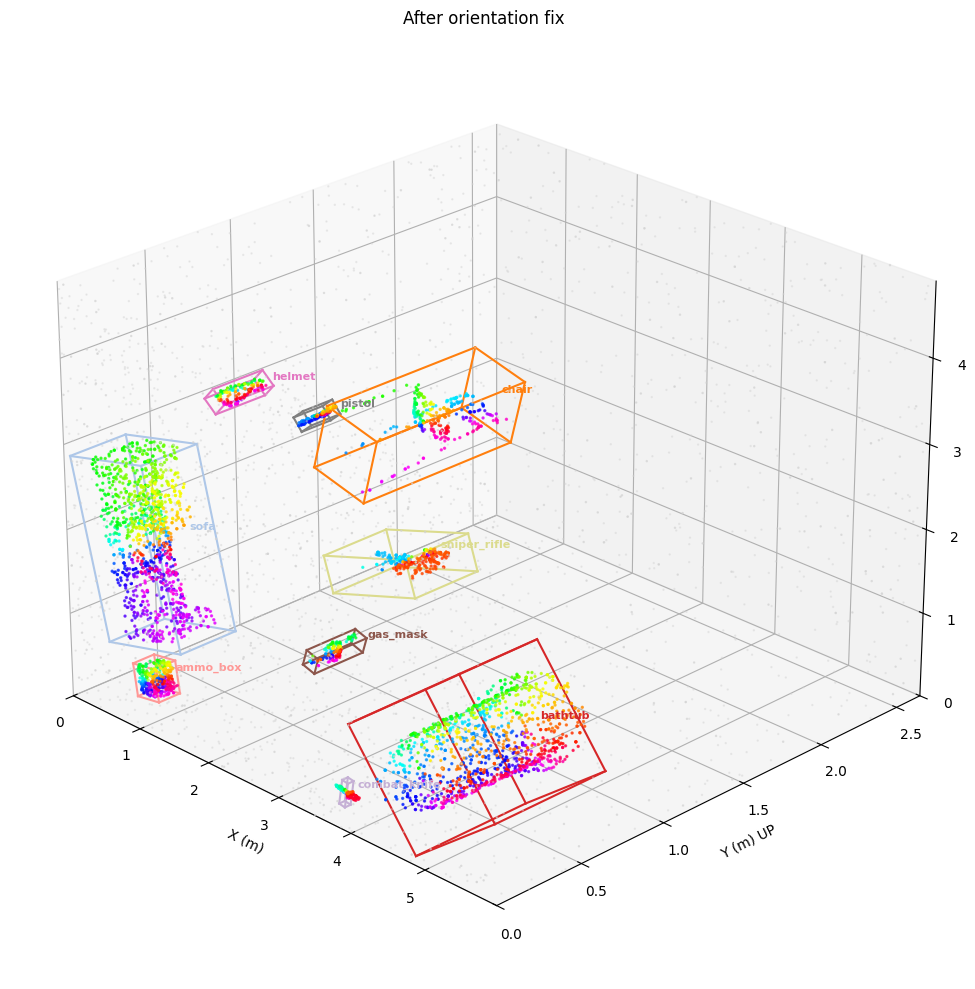

In [12]:
# Clear the cache (old meshes were loaded with bad orientation)
MESH_CACHE.clear()
print('Cache cleared.')

# Re-generate the 5 test scenes
print('Re-generating 5 test scenes with fixed orientation...\n')
test_scenes = []
attempts = 0
while len(test_scenes) < 5 and attempts < 20:
    attempts += 1
    scene = generate_scene()
    if scene is not None:
        test_scenes.append(scene)

# Print bbox table for scene 0 to verify heights are now sensible
scene = test_scenes[0]
bboxes = scene['bbox']
room_x, room_y, room_z = scene['_room_dims']

print(f'Room: {room_x:.2f} x {room_y:.2f} x {room_z:.2f}m\n')
print(f'{"Class":15s} {"cx":>6s} {"cy":>6s} {"cz":>6s} {"l":>5s} {"h":>5s} {"w":>5s}  expected')
print('-' * 70)
EXPECTED = {
    'bed': (1.8, 2.0, 0.4, 0.7),  # (l_min, l_max, h_min, h_max)
    'sofa': (1.5, 2.3, 0.6, 1.0), 'table': (0.8, 1.8, 0.5, 0.9),
    'chair': (0.4, 0.8, 0.7, 1.1), 'pistol': (0.15, 0.30, 0.05, 0.20),
    'rifle': (0.7, 1.1, 0.05, 0.30), 'shotgun': (0.7, 1.1, 0.05, 0.30),
    'sniper_rifle': (1.0, 1.4, 0.05, 0.30), 'helmet': (0.20, 0.35, 0.15, 0.30),
    'toilet': (0.4, 0.8, 0.6, 0.9), 'bookshelf': (0.6, 1.2, 1.5, 2.2),
}
for box in bboxes:
    cx, cy, cz, l, h, w, heading, cls_idx = box
    name = CLASS_NAMES[int(cls_idx)]
    exp = EXPECTED.get(name, None)
    if exp:
        ok = '✅' if (exp[0] <= l <= exp[1] or exp[0] <= w <= exp[1]) and exp[2] <= h <= exp[3] else '⚠️'
        marker = f'{ok} l~{exp[0]}-{exp[1]}m, h~{exp[2]}-{exp[3]}m'
    else:
        marker = ''
    print(f'{name:15s} {cx:6.2f} {cy:6.2f} {cz:6.2f} {l:5.2f} {h:5.2f} {w:5.2f}  {marker}')

# Re-visualize the side view to see if heights look right
visualize_scene(test_scenes[0], title='After orientation fix')

## Room Sanity Check

Room: 5.94 x 2.66 x 4.88m (X, Y_up, Z)

Class               cx     cy     cz     l     h     w   min_y   max_y
---------------------------------------------------------------------------
gas_mask          3.48   0.14   1.78  0.20  0.28  0.16   0.000   0.280 ✅
sofa              0.86   0.16   2.02  1.08  0.32  2.08   0.000   0.320 ✅
bathtub           4.95   0.33   1.09  1.46  0.65  1.32   0.000   0.650 ✅
pistol            3.42   0.08   4.46  0.17  0.16  0.16   0.000   0.164 ✅
sniper_rifle      4.29   0.18   3.05  1.14  0.36  0.40   0.000   0.358 ✅
ammo_box          1.11   0.06   0.60  0.31  0.12  0.38   0.000   0.122 ✅
chair             3.99   0.43   4.30  0.67  0.85  0.76   0.000   0.850 ✅
helmet            2.22   0.14   4.26  0.20  0.28  0.19   0.000   0.280 ✅
combat_knife      3.91   0.02   0.43  0.30  0.03  0.08   0.000   0.033 ✅


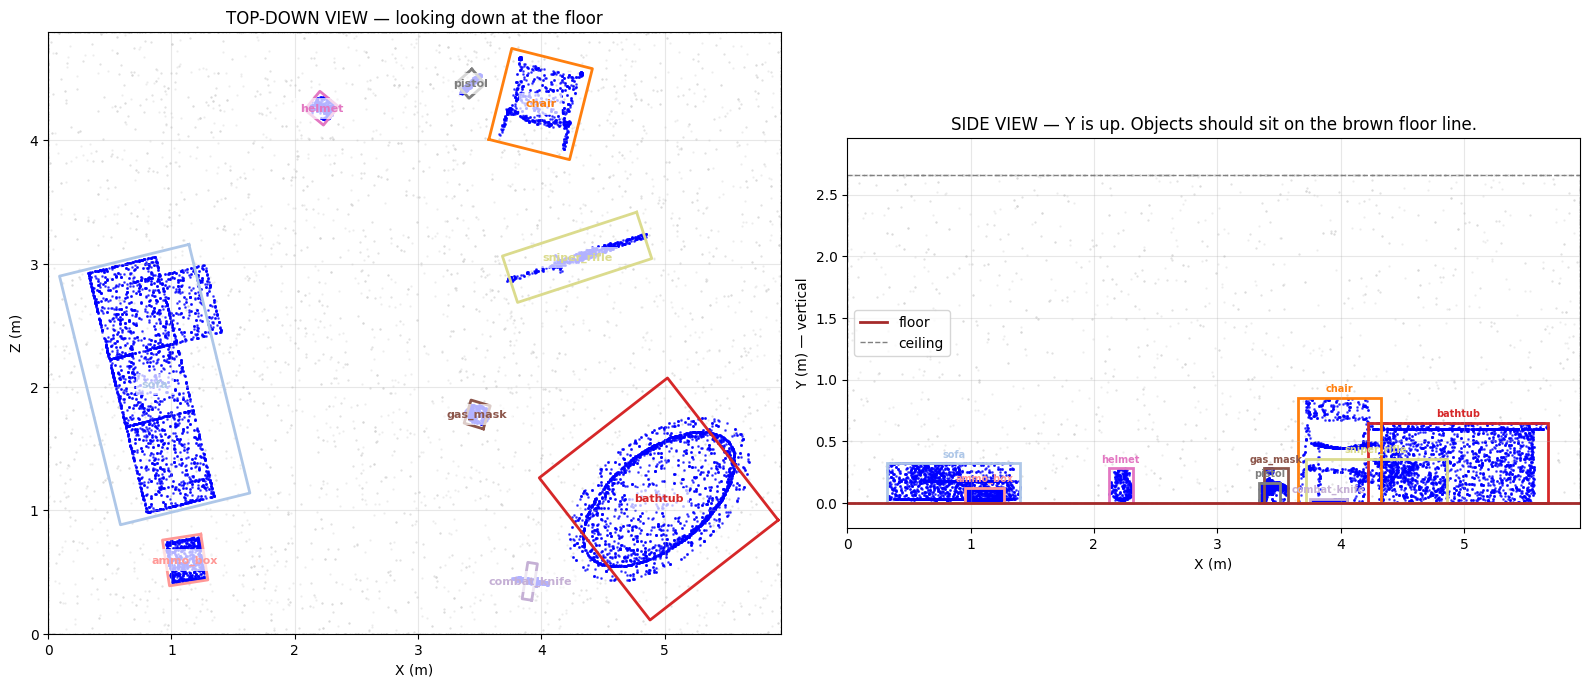

In [13]:
# ============================================
# Cell 4b — Bbox sanity check + top-down + side views
# ============================================
import matplotlib.pyplot as plt

scene = test_scenes[0]
bboxes = scene['bbox']
room_x, room_y, room_z = scene['_room_dims']

# === 1. Print bbox details — should show min_Y ≈ 0 for all objects (on floor) ===
print(f'Room: {room_x:.2f} x {room_y:.2f} x {room_z:.2f}m (X, Y_up, Z)\n')
print(f'{"Class":15s} {"cx":>6s} {"cy":>6s} {"cz":>6s} {"l":>5s} {"h":>5s} {"w":>5s} {"min_y":>7s} {"max_y":>7s}')
print('-' * 75)
for box in bboxes:
    cx, cy, cz, l, h, w, heading, cls_idx = box
    min_y = cy - h/2
    max_y = cy + h/2
    name = CLASS_NAMES[int(cls_idx)]
    floor_check = '✅' if abs(min_y) < 0.1 else '⚠️'
    print(f'{name:15s} {cx:6.2f} {cy:6.2f} {cz:6.2f} {l:5.2f} {h:5.2f} {w:5.2f} {min_y:7.3f} {max_y:7.3f} {floor_check}')

# === 2. Top-down view (looking down at the floor) ===
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax_top = axes[0]
pc = scene['pc'][:, :3]
is_fg = scene['votes'][:, 0] > 0.5
ax_top.scatter(pc[~is_fg, 0], pc[~is_fg, 2], c='lightgray', s=0.3, alpha=0.4)
ax_top.scatter(pc[is_fg, 0], pc[is_fg, 2], c='blue', s=1, alpha=0.6)

colors = plt.cm.tab20(np.linspace(0, 1, NUM_CLASSES))
for box in bboxes:
    cx, cy, cz, l, h, w, heading, cls_idx = box
    cls_idx = int(cls_idx)
    # Rotated box in XZ plane
    cosh, sinh = np.cos(heading), np.sin(heading)
    corners = np.array([[-l/2, -w/2], [l/2, -w/2], [l/2, w/2], [-l/2, w/2], [-l/2, -w/2]])
    R = np.array([[cosh, sinh], [-sinh, cosh]])
    corners = corners @ R.T + [cx, cz]
    ax_top.plot(corners[:, 0], corners[:, 1], color=colors[cls_idx], linewidth=2)
    ax_top.text(cx, cz, CLASS_NAMES[cls_idx], fontsize=8, ha='center', va='center',
                color=colors[cls_idx], weight='bold',
                bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

ax_top.set_xlim(0, room_x); ax_top.set_ylim(0, room_z)
ax_top.set_xlabel('X (m)'); ax_top.set_ylabel('Z (m)')
ax_top.set_title('TOP-DOWN VIEW — looking down at the floor')
ax_top.set_aspect('equal')
ax_top.grid(True, alpha=0.3)

# === 3. Side view (looking from outside, Y is vertical) ===
ax_side = axes[1]
ax_side.scatter(pc[~is_fg, 0], pc[~is_fg, 1], c='lightgray', s=0.3, alpha=0.4)
ax_side.scatter(pc[is_fg, 0], pc[is_fg, 1], c='blue', s=1, alpha=0.6)

for box in bboxes:
    cx, cy, cz, l, h, w, heading, cls_idx = box
    cls_idx = int(cls_idx)
    # Side view: project on XY plane — just show as axis-aligned rect since we don't have heading info on the side
    from matplotlib.patches import Rectangle
    rect = Rectangle((cx - l/2, cy - h/2), l, h, fill=False,
                     edgecolor=colors[cls_idx], linewidth=2)
    ax_side.add_patch(rect)
    ax_side.text(cx, cy + h/2 + 0.05, CLASS_NAMES[cls_idx], fontsize=7,
                 ha='center', color=colors[cls_idx], weight='bold')

ax_side.axhline(y=0, color='brown', linewidth=2, label='floor')
ax_side.axhline(y=room_y, color='gray', linewidth=1, linestyle='--', label='ceiling')
ax_side.set_xlim(0, room_x); ax_side.set_ylim(-0.2, room_y + 0.3)
ax_side.set_xlabel('X (m)'); ax_side.set_ylabel('Y (m) — vertical')
ax_side.set_title('SIDE VIEW — Y is up. Objects should sit on the brown floor line.')
ax_side.set_aspect('equal')
ax_side.legend()
ax_side.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Generating 5000 train and  1000 validation scenes

In [ ]:
# ============================================
# Cell 5 — Generate full synthetic dataset
# ============================================
import time
from tqdm import tqdm
from collections import Counter

# Output directory
SYNTH_ROOT = Path('/Users/dosvatsky/3D Object Detection/data/synthetic_v1')
TRAIN_DIR = SYNTH_ROOT / 'train'
VAL_DIR = SYNTH_ROOT / 'val'
TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)

N_TRAIN = 5000
N_VAL = 1000

print(f'Generating {N_TRAIN} train + {N_VAL} val scenes')
print(f'Output: {SYNTH_ROOT}')
print()

class_counter = Counter()
failed = 0
t_start = time.time()

# Warmup — preload all meshes into cache (so timing estimate is accurate)
print('Warming up mesh cache...')
for cls, paths in MESH_REGISTRY.items():
    for p in paths[:1]:  # first mesh per class
        try:
            load_normalized_mesh(p, cls)
        except Exception:
            pass

# === Generate train set ===
print(f'\nGenerating {N_TRAIN} training scenes...')
saved = 0
pbar = tqdm(total=N_TRAIN)
while saved < N_TRAIN:
    scene = generate_scene()
    if scene is None:
        failed += 1
        continue
    save_scene(scene, saved, TRAIN_DIR)
    for box in scene['bbox']:
        class_counter[CLASS_NAMES[int(box[7])]] += 1
    saved += 1
    pbar.update(1)
pbar.close()

t_train = time.time() - t_start
print(f'\nTrain done in {t_train/60:.1f} min ({t_train/N_TRAIN:.2f}s per scene)')

# === Generate val set ===
print(f'\nGenerating {N_VAL} validation scenes...')
val_start = time.time()
saved_val = 0
pbar = tqdm(total=N_VAL)
while saved_val < N_VAL:
    scene = generate_scene()
    if scene is None:
        failed += 1
        continue
    save_scene(scene, saved_val, VAL_DIR)
    for box in scene['bbox']:
        class_counter[CLASS_NAMES[int(box[7])]] += 1
    saved_val += 1
    pbar.update(1)
pbar.close()

t_val = time.time() - val_start
print(f'\nVal done in {t_val/60:.1f} min')

# === Statistics ===
print('\n' + '='*60)
print('DATASET STATISTICS')
print('='*60)
print(f'Total scenes: {N_TRAIN + N_VAL}')
print(f'Total objects: {sum(class_counter.values())}')
print(f'Failed attempts: {failed}')
print(f'\nClass distribution (instances across all scenes):')
print(f'{"Class":18s} {"count":>7s}  {"avg/scene":>10s}')
print('-' * 50)
for cls in CLASS_NAMES:
    cnt = class_counter[cls]
    avg = cnt / (N_TRAIN + N_VAL)
    bar = '█' * int(avg * 10)
    print(f'{cls:18s} {cnt:>7d}  {avg:>9.2f}  {bar}')

# Write class index file (required by VoteNet trainer)
with open(SYNTH_ROOT / 'classes.txt', 'w') as f:
    for i, c in enumerate(CLASS_NAMES):
        f.write(f'{i}\t{c}\n')

# Write split files
with open(SYNTH_ROOT / 'train_idx.txt', 'w') as f:
    f.writelines(f'{i:06d}\n' for i in range(N_TRAIN))
with open(SYNTH_ROOT / 'val_idx.txt', 'w') as f:
    f.writelines(f'{i:06d}\n' for i in range(N_VAL))

print(f'\nWrote {SYNTH_ROOT}/classes.txt')
print(f'Wrote {SYNTH_ROOT}/train_idx.txt ({N_TRAIN} entries)')
print(f'Wrote {SYNTH_ROOT}/val_idx.txt ({N_VAL} entries)')
print(f'\nTotal time: {(time.time() - t_start)/60:.1f} min')
print('Done — ready for Phase 8.3 (fine-tuning)')

Generating 5000 train + 1000 val scenes
Output: /Users/dosvatsky/3D Object Detection/data/synthetic_v1

Warming up mesh cache...

Generating 5000 training scenes...


 33%|███▎      | 1656/5000 [17:59<24:46,  2.25it/s]  